                Stage  Users  Conversion Rate (%)  Users Lost
0        visited_site    200               100.00         0.0
1      signup_started    150                75.00        50.0
2      details_filled     96                64.00        54.0
3      email_verified     52                54.17        44.0
4  purchase_completed     44                84.62         8.0

Biggest Drop-off:
signup_started → details_filled


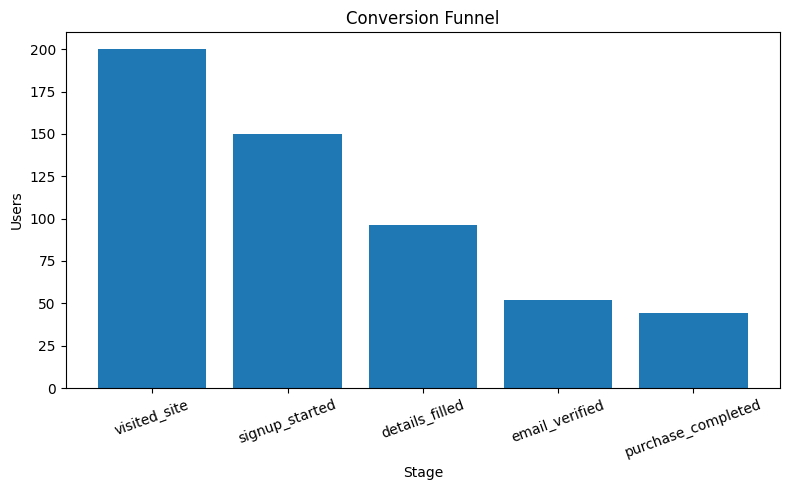

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("funnel_events_sample.csv")

# Funnel order
steps = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

# Remove duplicate user-step events
df = df.drop_duplicates(subset=["user_id","step"])

# Count users
counts = []

for step in steps:
    counts.append(df[df["step"]==step]["user_id"].nunique())

# Create summary
summary = pd.DataFrame({
    "Stage":steps,
    "Users":counts
})

summary["Conversion Rate (%)"] = (
    summary["Users"] /
    summary["Users"].shift(1) * 100
).round(2)

summary.loc[0,"Conversion Rate (%)"] = 100

summary["Users Lost"] = (
    summary["Users"].shift(1)-summary["Users"]
)

summary.loc[0,"Users Lost"]=0

print(summary)

# Biggest dropoff
idx = summary["Users Lost"].idxmax()

print("\nBiggest Drop-off:")
print(
    summary.loc[idx-1,"Stage"],
    "→",
    summary.loc[idx,"Stage"]
)

# Save CSV
summary.to_csv("funnel_summary.csv",index=False)

# Funnel chart
plt.figure(figsize=(8,5))
plt.bar(summary["Stage"],summary["Users"])
plt.title("Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("funnel_chart.png")
plt.show()